# **Assignment 2**: Feature Extraction and Latent Space Visualization with t-SNE

**Objective:** Visualize learned feature representations from a pretrained CNN using t-SNE.

**Tasks:**
* Load MNIST and a pretrained CNN (e.g., ResNet-18).

* Extract features from the penultimate layer.

* Use ~1000 samples to compute embeddings.

* Apply t-SNE (2D/3D) and visualize with class-wise coloring.

* Compare t-SNE on raw pixels vs deep features.

* (Optional) Apply PCA before t-SNE.

**Deliverables:**
* t-SNE plots (raw vs latent features)

* Code snippet for feature extraction

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(224), #  as resnet-18 trained on fixed 128X128 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

dataset = torchvision.datasets.CIFAR10(root="./data",
                                       train=False,
                                       download=True,
                                       transform=transform
)

subset_size = 1000
indices = np.random.choice(len(dataset), subset_size, replace=False)
subset = torch.utils.data.Subset(dataset, indices) # selecting random ~1000 samples

loader = torch.utils.data.DataLoader(subset,
                                     batch_size=64,
                                     shuffle=False)

In [5]:
model = torchvision.models.resnet18(pretrained=True)
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
def extract_features(model, data_loader, device):
    features_list = []
    labels_list = []

    # Remove the final classification layer
    # For ResNet, the penultimate layer output is before the 'fc' layer.
    # We can effectively extract features by removing or ignoring the 'fc' layer.
    # A simpler way is to hook into the output of the avgpool layer.

    # We'll use a hook to get the output of the avgpool layer
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook

    # Register the hook on the 'avgpool' layer
    hook_handle = model.avgpool.register_forward_hook(get_activation('avgpool'))

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            # Perform a forward pass, the hook will capture the avgpool output
            _ = model(images)

            # The features are in activation['avgpool']
            # We need to squeeze (remove dimensions of size 1) and flatten if necessary
            penultimate_features = activation['avgpool'].squeeze().cpu().numpy()
            features_list.append(penultimate_features)
            labels_list.append(labels.cpu().numpy())

    hook_handle.remove() # Don't forget to remove the hook!

    return np.concatenate(features_list, axis=0), np.concatenate(labels_list, axis=0)

print("Extracting features...")
features, labels = extract_features(model, loader, device)
print(f"Extracted features shape: {features.shape}")
print(f"Extracted labels shape: {labels.shape}")

Extracting features...
Extracted features shape: (1000, 512)
Extracted labels shape: (1000,)


### Explanation of the Feature Extraction Code:

1.  **`extract_features(model, data_loader, device)` function**: This function is designed to take your pre-trained `model`, the `data_loader` (which contains your subset of images), and the `device` (CPU/GPU).

2.  **Hooking into the `avgpool` layer**:
    *   We define `activation = {}` to store the output of the layer we're interested in.
    *   `get_activation(name)` is a higher-order function that returns a `hook` function. This `hook` function will be called whenever a forward pass is made through the registered module.
    *   `model.avgpool.register_forward_hook(get_activation('avgpool'))` registers our hook to the `avgpool` layer of the ResNet model. This means that every time data passes through `model.avgpool`, its output will be stored in `activation['avgpool']`.

3.  **`with torch.no_grad():`**: This context manager disables gradient calculation, which is important during inference (feature extraction) to save memory and speed up computation, as we don't need to update model weights.

4.  **Iteration and Forward Pass**: The code iterates through the `data_loader`.
    *   `images = images.to(device)` moves the image batch to the appropriate device.
    *   `_ = model(images)` performs a forward pass through the entire model. Even though we are not directly using the final output (the `_` variable), this step is necessary to trigger the `avgpool` layer and thus our hook.

5.  **Capturing Features**:
    *   `penultimate_features = activation['avgpool'].squeeze().cpu().numpy()` retrieves the output captured by the hook. `.squeeze()` removes any dimensions of size 1 (e.g., from `(batch_size, 512, 1, 1)` to `(batch_size, 512)`), `.cpu()` moves the tensor to the CPU, and `.numpy()` converts it to a NumPy array for easier handling.
    *   These features and their corresponding `labels` are appended to lists.

6.  **`hook_handle.remove()`**: It's crucial to remove the hook after extraction to prevent memory leaks and ensure the model behaves normally in subsequent operations.

7.  **Concatenation**: Finally, all collected features and labels from different batches are concatenated into single NumPy arrays.

In [7]:
raw_pixels = []

for images, _ in loader:
    images = images.view(images.size(0), -1)   # flatten 3×224×224
    raw_pixels.append(images.numpy())

raw_pixels = np.concatenate(raw_pixels, axis=0)


In [8]:
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)
raw_pca = pca.fit_transform(raw_pixels)


In [9]:
tsne_deep = TSNE(n_components=2, perplexity=30, random_state=42)
deep_2d = tsne_deep.fit_transform(features_pca)


In [12]:
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42)
raw_2d = tsne_raw.fit_transform(raw_pca)


In [25]:
def plot_tsne(embeddings, labels, title):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=labels,
        cmap="tab10",
        s=15
    )
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()


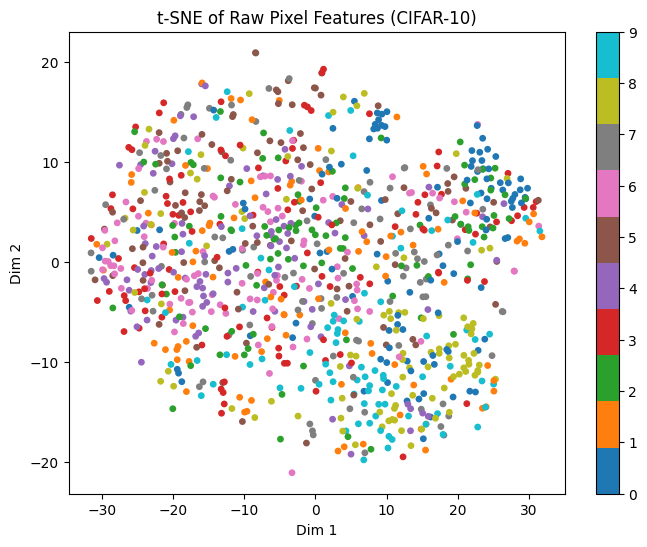

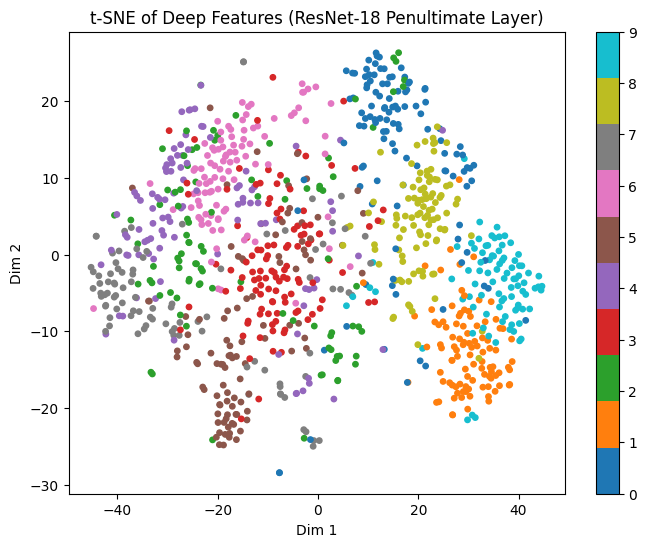

In [26]:
plot_tsne(raw_2d, labels, "t-SNE of Raw Pixel Features (CIFAR-10)")
plot_tsne(deep_2d, labels, "t-SNE of Deep Features (ResNet-18 Penultimate Layer)")
